In [4]:
import pandas as pd
import numpy as np

# Load dataset
data = pd.read_csv("/content/Brain Tumor.csv")

# Show first 5 rows
data.head()

,Image,Class,Mean,Variance,Standard Deviation,Entropy,Skewness,Kurtosis,Contrast,Energy,ASM,Homogeneity,Dissimilarity,Correlation,Coarseness
0,Image1,0,6.535339,619.587845,24.891522,0.109059,4.276477,18.900575,98.613971,0.293314,0.086033,0.530941,4.473346,0.981939,7.458341e-155
1,Image2,0,8.749969,805.957634,28.389393,0.266538,3.718116,14.464618,63.858816,0.475051,0.225674,0.651352,3.220072,0.988834,7.458341e-155
2,Image3,1,7.341095,1143.808219,33.820234,0.001467,5.061750,26.479563,81.867206,0.031917,0.001019,0.268275,5.981800,0.978014,7.458341e-155
3,Image4,1,5.958145,959.711985,30.979219,0.001477,5.677977,33.428845,151.229741,0.032024,0.001026,0.243851,7.700919,0.964189,7.458341e-155
4,Image5,0,7.315231,729.540579,27.010009,0.146761,4.283221,19.079108,174.988756,0.343849,0.118232,0.501140,6.834689,0.972789,7.458341e-155


In [11]:
# Check null values
print(data.isnull().sum())

# Split features and target
X = data.drop('Class', axis=1)   # features
y = data['Class']                # label

# Convert to numpy
X = np.array(X)
y = np.array(y)

Image                 0
Class                 0
Mean                  0
Variance              0
Standard Deviation    0
Entropy               0
Skewness              0
Kurtosis              0
Contrast              0
Energy                0
ASM                   0
Homogeneity           0
Dissimilarity         0
Correlation           0
Coarseness            0
dtype: int64


In [15]:
# Handle column names
data.columns = data.columns.str.strip()

# Define target (last column safest)
target_column = data.columns[-1]

X = data.drop(target_column, axis=1)
y = data[target_column]

# Convert categorical to numeric
X = pd.get_dummies(X, drop_first=True)

# Handle missing values
X = X.fillna(X.mean())

# Encode target if needed
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

# Split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Create model
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       241,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243,713 (952.00 KB)

 Trainable params: 243,713 (952.00 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    validation_data=(X_test, y_test),
    batch_size=32
)

Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.0223 - loss: -59.3874 - val_accuracy: 0.0013 - val_loss: -1145.1450
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 9.9701e-04 - loss: -2664.3533 - val_accuracy: 0.0013 - val_loss: -13791.1855
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 9.9701e-04 - loss: -16356.7812 - val_accuracy: 0.0013 - val_loss: -56976.4414
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 9.9701e-04 - loss: -50483.1680 - val_accuracy: 0.0013 - val_loss: -145676.0000
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 9.9701e-04 - loss: -111753.9219 - val_accuracy: 0.0013 - val_loss: -287826.4062
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 9.9701e-04 - loss: -203425.0156 - val_accuracy: 0.0013 - val_loss: -492129.0625
Epoch 7/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 9.9701e-04 - loss: -334755.9688 - val_accuracy: 0.0013 - val_loss: -777229.4375
Epoch 8/20
95/95 ━━━━

In [18]:
loss, acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", acc)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0013 - loss: -13552811.0000
Test Accuracy: 0.0013280212879180908


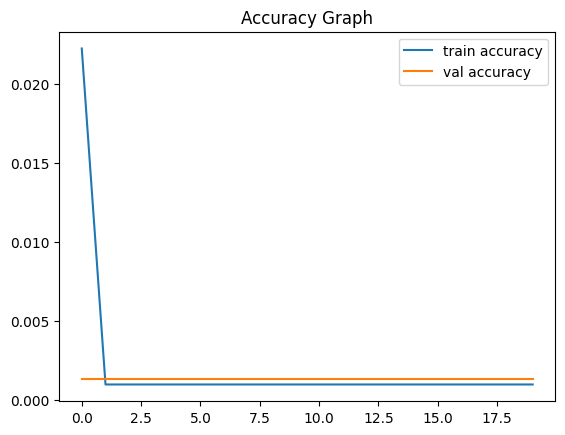

In [19]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

In [20]:
# Take one sample
sample = X_test[0].reshape(1, -1)

prediction = model.predict(sample)

print("Prediction value:", prediction)

if prediction[0][0] > 0.5:
    print("Tumor")
else:
    print("No Tumor")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Prediction value: [[1.]]
Tumor
